In [1]:
!mkdir -p train/
!mkdir -p val/
!wget http://submit08.mit.edu/~bmaier/STEAM/HBB_098.root 
!wget http://submit08.mit.edu/~bmaier/STEAM/HBB_099.root 
!wget http://submit08.mit.edu/~bmaier/STEAM/QCD_098.root 
!wget http://submit08.mit.edu/~bmaier/STEAM/QCD_099.root 
!mv *root train/

!wget http://submit08.mit.edu/~bmaier/STEAM/HBB_097.root 
!wget http://submit08.mit.edu/~bmaier/STEAM/QCD_097.root 
!mv *root val/

--2026-08-18 18:12:32--  http://submit08.mit.edu/~bmaier/STEAM/HBB_098.root
Resolving submit08.mit.edu (submit08.mit.edu)... 18.4.134.169, 2603:4000:486:1::169
Connecting to submit08.mit.edu (submit08.mit.edu)|18.4.134.169|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 377184538 (360M)
Saving to: ‘HBB_098.root’

HBB_098.root        100%[===================>] 359.71M  3.94MB/s    in 82s     

2026-08-18 18:13:54 (4.38 MB/s) - ‘HBB_098.root’ saved [377184538/377184538]

--2026-08-18 18:13:54--  http://submit08.mit.edu/~bmaier/STEAM/HBB_099.root
Resolving submit08.mit.edu (submit08.mit.edu)... 18.4.134.169, 2603:4000:486:1::169
Connecting to submit08.mit.edu (submit08.mit.edu)|18.4.134.169|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 376810913 (359M)
Saving to: ‘HBB_099.root’

HBB_099.root        100%[===================>] 359.35M  3.00MB/s    in 86s     

2026-08-18 18:15:20 (4.20 MB/s) - ‘HBB_099.root’ saved [376810913/376810913]

--

# Multimodal jet tagging: particles $+$ Lund splittings

**Following PLuM --- *Particle-Lund Multimodality in Jet Taggers* (arXiv:2605.26821).**

Two views of the same jet:

- **particles** --- the constituents, as a set of kinematic features,
- **Lund splittings** --- the declustering tree, an explicit, physics-motivated
  representation of the QCD radiation pattern.

The recipe is the generic multimodal one: give each modality its own encoder, project both into
the **same** $d$-dimensional space, concatenate into one sequence, and let a single transformer
attend over the union. Attention does not care which modality a token came from.

Then the question this notebook actually asks: **do individual heads specialise?** We measure,
for every head, how much of its attention mass flows

| | to particles | to splittings |
|---|---|---|
| **from particles** | P$\to$P | P$\to$S |
| **from splittings** | S$\to$P | S$\to$S |

and compare against what a head with no preference would give.

In [2]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import math, time
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

PART_FEATS  = ['part_pt_log','part_e_log','part_logptrel','part_logerel',
               'part_deltaR','part_d0','part_dz']
SPLIT_FEATS = ['split_z_log','split_kt_log','split_delta_log']
NPART, NSPLIT = 128, 48          # padded lengths

device: cuda | torch 2.10.0


---
## 1. Load QCD and H->bb jets

Expected per jet: the particle branches padded to `NPART`, the splitting branches padded to
`NSPLIT`, plus the two masks. Adjust `load_files` to your format --- the rest of the notebook
only needs the six arrays returned.

In [3]:
import os, glob, uproot, awkward as ak

TRAIN_DIR   = "train"
SIG_PATTERN = "HBB_*.root"
BKG_PATTERN = "QCD_*.root"
TREE        = "tree"
MAX_PER_CLASS = None

# raw branches actually stored in the file -- check these names against yours
RAW = ['part_px', 'part_py', 'part_energy', 'part_deta', 'part_dphi',
       'part_d0val', 'part_dzval',
       'split_z', 'split_kt', 'split_delta',
       'jet_pt', 'jet_energy']

EPS = 1e-8

def derive(a):
    """Build the model features from raw branches, on the jagged arrays.
    jet_pt / jet_energy are per-jet scalars; awkward broadcasts them."""
    part_pt = np.hypot(a['part_px'], a['part_py'])
    P = {
        'part_pt_log':   np.log(np.maximum(part_pt, EPS)),
        'part_e_log':    np.log(np.maximum(a['part_energy'], EPS)),
        'part_logptrel': np.log(np.maximum(part_pt / a['jet_pt'], EPS)),
        'part_logerel':  np.log(np.maximum(a['part_energy'] / a['jet_energy'], EPS)),
        'part_deltaR':   np.hypot(a['part_deta'], a['part_dphi']),
        'part_d0':       np.tanh(a['part_d0val']),
        'part_dz':       np.tanh(a['part_dzval']),
    }
    S = {
        'split_z_log':     np.log(np.maximum(a['split_z'],     EPS)),
        'split_kt_log':    np.log(np.maximum(a['split_kt'],    EPS)),
        'split_delta_log': np.log(np.maximum(a['split_delta'], EPS)),
    }
    return P, S, ak.ones_like(a['part_energy']), ak.ones_like(a['split_kt'])

def _pad(x, n):
    return ak.to_numpy(ak.fill_none(ak.pad_none(x, n, clip=True), 0.0)).astype(np.float32)

def load_class(pattern, label, tree=TREE, maxn=MAX_PER_CLASS):
    files = sorted(glob.glob(os.path.join(TRAIN_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"no files matching {TRAIN_DIR}/{pattern}")
    a = uproot.concatenate([f"{f}:{tree}" for f in files], RAW, library="ak")
    if maxn is not None:
        a = a[:maxn]
    Pf, Sf, mp, ms = derive(a)
    P  = np.stack([_pad(Pf[b], NPART)  for b in PART_FEATS],  -1)
    S  = np.stack([_pad(Sf[b], NSPLIT) for b in SPLIT_FEATS], -1)
    pm = _pad(mp, NPART); sm = _pad(ms, NSPLIT)
    y  = np.full(len(P), label, np.float32)
    print(f"  {pattern:14s} {len(files):3d} files -> {len(P):7,} jets")
    return P, S, pm, sm, y

print("loading from", TRAIN_DIR + "/")
sig = load_class(SIG_PATTERN, 1.0)
bkg = load_class(BKG_PATTERN, 0.0)
XP, XS, MP, MS, Y = [np.concatenate([b, s]) for b, s in zip(bkg, sig)]

# shuffle before splitting -- the classes were concatenated
perm = np.random.default_rng(0).permutation(len(Y))
XP, XS, MP, MS, Y = XP[perm], XS[perm], MP[perm], MS[perm], Y[perm]
ntr = int(0.8*len(Y)); tr, te = slice(0, ntr), slice(ntr, len(Y))

print(f"\ntotal {len(Y):,} jets | signal fraction {Y.mean():.3f}")
print("particles ", XP.shape, " splittings", XS.shape)
print("mean particles/jet ", round(float(MP.sum(1).mean()),1),
      "| mean splittings/jet", round(float(MS.sum(1).mean()),1))
print(f"clipped at NPART={NPART}:  {float((MP.sum(1)>=NPART).mean()):.1%} of jets")
print(f"clipped at NSPLIT={NSPLIT}: {float((MS.sum(1)>=NSPLIT).mean()):.1%} of jets")

# sanity: nothing infinite or NaN survived the logs
for name, A, M in (("particles", XP, MP), ("splittings", XS, MS)):
    v = A[M > 0]
    print(f"{name:11s} finite {np.isfinite(v).all()} | "
          f"min {v.min(0).round(2)} max {v.max(0).round(2)}")

# standardise on training statistics only
def fit_stats(A, M):
    f = A[:ntr][M[:ntr] > 0]; return f.mean(0), f.std(0) + 1e-6
def apply_stats(A, M, mu, sd):
    return ((A - mu)/sd * M[..., None]).astype(np.float32)

mu_p, sd_p = fit_stats(XP, MP); mu_s, sd_s = fit_stats(XS, MS)
XP = apply_stats(XP, MP, mu_p, sd_p); XS = apply_stats(XS, MS, mu_s, sd_s)

loading from train/
  HBB_*.root       2 files -> 200,000 jets
  QCD_*.root       2 files -> 200,000 jets

total 400,000 jets | signal fraction 0.500
particles  (400000, 128, 7)  splittings (400000, 48, 3)
mean particles/jet  38.7 | mean splittings/jet 32.3
clipped at NPART=128:  0.0% of jets
clipped at NSPLIT=48: 11.1% of jets
particles   finite True | min [-2.57 -1.41 -9.26 -8.54  0.   -1.   -1.  ] max [6.85 7.85 0.   0.   3.3  1.   1.  ]
splittings  finite True | min [ -7.65 -11.37 -14.18] max [-0.69  5.97 -0.22]


---
## 2. The model

Two encoders, one space, one transformer.

- `Linear(7 -> d)` for particles, `Linear(3 -> d)` for splittings.
- A learned **modality embedding** added to each, so the model can tell them apart if it wants to (without being forced to).
- Concatenate into one sequence of length `NPART + NSPLIT`, then plain multi-head
  self-attention. No block structure, no prior bias: a splitting token may attend to any particle
  and vice versa.

Attention is written out by hand so the per-head weights can be inspected afterwards.

In [4]:
class MHA(nn.Module):
    def __init__(self, d, nheads):
        super().__init__()
        self.h, self.dh = nheads, d//nheads
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.o   = nn.Linear(d, d, bias=False)
        self.attn = None                                    # (B,H,L,L), kept for inspection
    def forward(self, x, mask, keep=False):
        B, L, D = x.shape; H, dh = self.h, self.dh
        q, k, v = self.qkv(x).chunk(3, -1)
        q, k, v = [t.view(B,L,H,dh).transpose(1,2) for t in (q,k,v)]
        s = (q @ k.transpose(-2,-1)) / math.sqrt(dh)
        s = s.masked_fill(mask[:,None,None,:] == 0, float('-inf'))
        a = torch.nan_to_num(s.softmax(-1))
        if keep: self.attn = a.detach()
        out = (a @ v).transpose(1,2).reshape(B,L,D)
        return self.o(out)

class Block(nn.Module):
    def __init__(self, d, nheads, ff):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.att = MHA(d, nheads)
        self.ff  = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, x, m, keep=False):
        x = x + self.att(self.n1(x), m, keep)
        return x + self.ff(self.n2(x))

def batches(idx_slice, bs, shuffle=True):
    n = len(Y[idx_slice])
    order = np.random.permutation(n) if shuffle else np.arange(n)
    for a in range(0, n, bs):
        j = order[a:a+bs]
        yield tuple(torch.from_numpy(v[idx_slice][j]).to(DEV)
                    for v in (XP, XS, MP, MS, Y))

---
## 3. Train

Binary QCD vs H->bb; scale up for better performance.

particles only   params 108,929  L=128  AUC 0.99411  rej@30%  2114.1  rej@10% 13389.0  (151s)
splittings only  params 108,673  L= 48  AUC 0.94311  rej@30%   144.0  rej@10%  1004.2  (60s)
PLuM (both)      params 117,889  L=176  AUC 0.99462  rej@30%  3347.2  rej@10% 20083.5  (283s)

extra parameters for the second modality: 8,960 (8.23% of the baseline)
attention cost:  L 128 -> 176  (1.89x the n^2 term)
gain: +0.0517% in AUC 


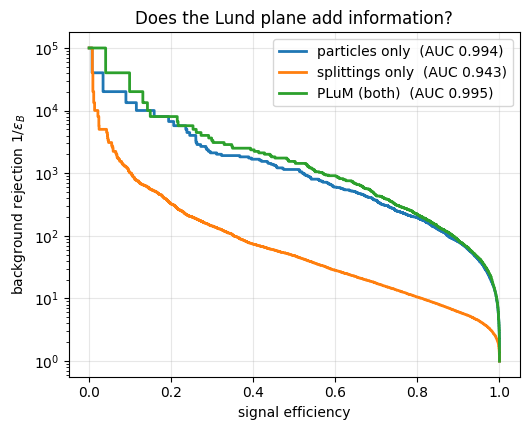

In [9]:
# ---------------------------------------------------------------
# Baselines. Each model only builds the encoders it needs; the
# multimodal one is a bit larger.
# ---------------------------------------------------------------
def feature_mlp(n_in, d, hidden=None):
    """3-layer per-token embedder, ParT-style: Linear -> Norm -> GELU, twice, then project to d."""
    h = hidden or d
    return nn.Sequential(
        nn.Linear(n_in, h), nn.LayerNorm(h), nn.GELU(),
        nn.Linear(h, h),    nn.LayerNorm(h), nn.GELU(),
        nn.Linear(h, d),
    )

class JetTagger(nn.Module):
    def __init__(self, npf, nsf, use_p=True, use_s=True,
                 d=64, nheads=4, nlayers=3, ff=128, emb_hidden=None):
        super().__init__()
        assert use_p or use_s
        self.use_p, self.use_s = use_p, use_s
        if use_p: self.emb_p = feature_mlp(npf, d, emb_hidden)
        if use_s: self.emb_s = feature_mlp(nsf, d, emb_hidden)
        # a modality embedding is only meaningful when both are present:
        # with one modality it is a constant, absorbed into the encoder bias.
        self.mod = nn.Embedding(2, d) if (use_p and use_s) else None
        self.blocks = nn.ModuleList([Block(d, nheads, ff) for _ in range(nlayers)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, 1)

    def forward(self, xp, xs, mp, ms, keep=False):
        hs, ms_ = [], []
        if self.use_p:
            h = self.emb_p(xp)
            if self.mod is not None: h = h + self.mod.weight[0][None, None]
            hs.append(h); ms_.append(mp)
        if self.use_s:
            h = self.emb_s(xs)
            if self.mod is not None: h = h + self.mod.weight[1][None, None]
            hs.append(h); ms_.append(ms)
        h = torch.cat(hs, 1); m = torch.cat(ms_, 1)
        for b in self.blocks: h = b(h, m, keep)
        h = self.nf(h)
        pooled = (h*m[..., None]).sum(1) / m.sum(1, keepdim=True).clamp(min=1)
        return self.head(pooled).squeeze(-1)

    def attentions(self):
        return [b.att.attn for b in self.blocks]


def metrics(probs, ys, effs=(0.3, 0.1)):
    order = np.argsort(-probs); s = ys[order]
    tpr = np.cumsum(s)/s.sum(); fpr = np.cumsum(1-s)/(1-s).sum()
    auc = float(np.trapezoid(tpr, fpr)) if hasattr(np, 'trapezoid') else float(np.trapz(tpr, fpr))
    sig, bkg = probs[ys > 0.5], probs[ys < 0.5]
    rej = {}
    for e in effs:
        thr = np.quantile(sig, 1-e)
        rej[e] = 1.0/max((bkg > thr).mean(), 1/len(bkg))
    return auc, rej, (fpr, tpr)


def train_eval(use_p=True, use_s=True, steps=6000, bs=128, seed=0):
    torch.manual_seed(seed)
    net = JetTagger(len(PART_FEATS), len(SPLIT_FEATS), use_p=use_p, use_s=use_s).to(DEV)
    nparam = sum(p.numel() for p in net.parameters())
    L = (NPART if use_p else 0) + (NSPLIT if use_s else 0)

    opt = torch.optim.AdamW(net.parameters(), lr=2e-3, betas=(0.9,0.95), weight_decay=0.01)
    sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s_: min((s_+1)/50, 1.0))
    step, t0 = 0, time.time(); net.train()
    while step < steps:
        for xp, xs, mp, ms, y in batches(tr, bs):
            loss = F.binary_cross_entropy_with_logits(net(xp, xs, mp, ms), y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0); opt.step(); sch.step()
            step += 1
            if step >= steps: break

    net.eval(); P, YS = [], []
    with torch.no_grad():
        for xp, xs, mp, ms, y in batches(te, 256, shuffle=False):
            P.append(torch.sigmoid(net(xp, xs, mp, ms)).cpu().numpy()); YS.append(y.cpu().numpy())
    P, YS = np.concatenate(P), np.concatenate(YS)
    auc, rej, roc = metrics(P, YS)
    return dict(auc=auc, rej=rej, roc=roc, nparam=nparam, L=L,
                secs=time.time()-t0, net=net)


configs = [("particles only",  True,  False),
           ("splittings only", False, True),
           ("PLuM (both)",     True,  True)]

res = {}
for name, up, us in configs:
    r = train_eval(use_p=up, use_s=us); res[name] = r
    print(f"{name:16s} params {r['nparam']:>7,}  L={r['L']:3d}  "
          f"AUC {r['auc']:.5f}  rej@30% {r['rej'][0.3]:7.1f}  rej@10% {r['rej'][0.1]:7.1f}"
          f"  ({r['secs']:.0f}s)", flush=True)

base, plum = res["particles only"], res["PLuM (both)"]
dp = plum['nparam'] - base['nparam']
print(f"\nextra parameters for the second modality: {dp:,} "
      f"({100*dp/base['nparam']:.2f}% of the baseline)")
print(f"attention cost:  L {base['L']} -> {plum['L']}  "
      f"({(plum['L']/base['L'])**2:.2f}x the n^2 term)")
print(f"gain: {100*(plum['auc']/base['auc']-1):+.4f}% in AUC ")

plt.figure(figsize=(5.4,4.4))
for name, _, _ in configs:
    fpr, tpr = res[name]["roc"]
    plt.plot(tpr, 1/np.clip(fpr, 1e-5, None), lw=2,
             label=f"{name}  (AUC {res[name]['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency")
plt.ylabel("background rejection $1/\\epsilon_B$")
plt.title("Does the Lund plane add information?"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# 4. Do heads specialise?

For each head we take the attention matrix, split the sequence into its two blocks, and measure
what fraction of each query's mass lands in each block.

A head with **no preference** would distribute mass in proportion to how many valid keys of each
type exist. So we report the **enrichment**

$$\text{enrichment} = \frac{\text{observed fraction}}{\text{expected fraction}}$$

with $>1$ meaning the head genuinely prefers that block.

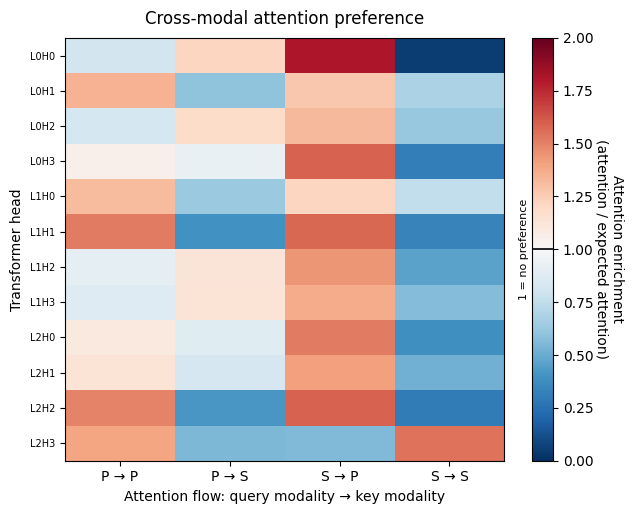

head        P->P    P->S    S->P    S->S   interpretation
L0H0        0.82    1.21    1.81    0.05   cross-modal (Lund reads P)
L0H1        1.35    0.59    1.27    0.68   particle-only
L0H2        0.83    1.19    1.32    0.62   cross-modal (Lund reads P)
L0H3        1.05    0.93    1.59    0.31   cross-modal (Lund reads P)
L1H0        1.31    0.63    1.21    0.76   particle-only
L1H1        1.52    0.40    1.57    0.33   cross-modal (Lund reads P)
L1H2        0.90    1.13    1.44    0.47   cross-modal (Lund reads P)
L1H3        0.87    1.14    1.37    0.57   cross-modal (Lund reads P)
L2H0        1.10    0.88    1.52    0.39   cross-modal (Lund reads P)
L2H1        1.13    0.83    1.41    0.52   cross-modal (Lund reads P)
L2H2        1.50    0.42    1.59    0.30   cross-modal (Lund reads P)
L2H3        1.40    0.55    0.56    1.54   particle-only


In [22]:
# Use the trained multimodal PLuM network
net = res["PLuM (both)"]["net"]
net.eval()

with torch.no_grad():
    xp, xs, mp, ms, y = next(batches(te, 256, shuffle=False))
    _ = net(xp, xs, mp, ms, keep=True)
    A = net.attentions()                              # list over layers of (B,H,L,L)
    m = torch.cat([mp, ms], 1)                        # (B,L)

isP = torch.zeros_like(m); isP[:, :NPART] = 1.0
isS = torch.zeros_like(m); isS[:, NPART:] = 1.0
isP, isS = isP*m, isS*m                               # valid particles / valid splittings

def block_table(a):
    """a: (B,H,L,L) -> fractions and enrichment, per head"""
    nP = isP.sum(1)
    nS = isS.sum(1)
    ntot = (nP+nS).clamp(min=1)

    expP, expS = (nP/ntot)[:,None], (nS/ntot)[:,None]

    res = {}
    for qname, qsel in (("P", isP), ("S", isS)):
        wq = qsel[:,None,:,None]
        denom = qsel.sum(1).clamp(min=1)[:,None]

        toP = (a*wq*isP[:,None,None,:]).sum((2,3)) / denom
        toS = (a*wq*isS[:,None,None,:]).sum((2,3)) / denom

        res[f"{qname}->P"] = (
            toP.mean(0).cpu().numpy(),
            (toP/expP).mean(0).cpu().numpy()
        )
        res[f"{qname}->S"] = (
            toS.mean(0).cpu().numpy(),
            (toS/expS).mean(0).cpu().numpy()
        )

    return res

rows, labels = [], []

for li, a in enumerate(A):
    tab = block_table(a)
    H = a.shape[1]

    for h in range(H):
        rows.append([
            tab[k][1][h]
            for k in ("P->P", "P->S", "S->P", "S->S")
        ])
        labels.append(f"L{li}H{h}")

E = np.array(rows)

fig, ax = plt.subplots(figsize=(6.5, 0.32*len(labels)+1.4))

im = ax.imshow(
    E,
    cmap="RdBu_r",
    vmin=0,
    vmax=2,
    aspect="auto"
)

ax.set_xticks(range(4))
ax.set_xticklabels([
    "P → P", "P → S", "S → P", "S → S"
])

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)

ax.set_xlabel("Attention flow: query modality → key modality")
ax.set_ylabel("Transformer head")

ax.set_title(
    "Cross-modal attention preference",
    fontsize=12,
    pad=10
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    "Attention enrichment\n"
    "(attention / expected attention)",
    rotation=270,
    labelpad=22
)

# Make the neutral point visually explicit
cbar.ax.axhline(1.0, color="black", lw=1.2)
cbar.ax.text(
    -0.6, 1.0, "1 = no preference", rotation=90,
    va="center", ha="left", fontsize=8
)

plt.tight_layout()
plt.show()

print(f"{'head':8s}{'P->P':>8}{'P->S':>8}{'S->P':>8}{'S->S':>8}   interpretation")

for lab, e in zip(labels, E):
    tag = (
        "cross-modal (P reads Lund)" if e[1] > 1.3 else
        "cross-modal (Lund reads P)" if e[2] > 1.3 else
        "particle-only"              if e[0] > 1.3 else
        "Lund-only"                  if e[3] > 1.3 else
        "mixed"
    )

    print(
        f"{lab:8s}{e[0]:8.2f}{e[1]:8.2f}"
        f"{e[2]:8.2f}{e[3]:8.2f}   {tag}"
    )